# Data Quality Assessment & Preprocessing

Dataset: Chocolate_Sales.csv

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Chocolate_Sales.csv")

print("Shape:", df.shape)
df.head()

Shape: (3282, 6)


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [2]:
display(df.info())
display(df.describe(include="all").T)

print("\nMissing values per column:")
display(df.isnull().sum())

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sales Person,3282,25,Kelci Walkden,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3282,6,Australia,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,3282,22,50% Dark Bites,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,3282,504,13/01/2022,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,3282,3013,"$2,317.00",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Boxes Shipped,3282.0,NaN,NaN,NaN,164.666971,124.024736,1.0,71.0,137.0,232.0,778.0



Missing values per column:


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


Duplicate rows: 0


In [3]:
df["Amount"] = df["Amount"].astype(str).replace(r"[\$,]", "", regex=True)
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Missing values after type conversion:")
display(df.isnull().sum())

df.head()

Missing values after type conversion:


Sales Person        0
Country             0
Product             0
Date             1992
Amount              0
Boxes Shipped       0
dtype: int64

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-04-01,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-01-08,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,NaT,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,NaT,13685.0,184


In [4]:
df = df.dropna(subset=["Date"]).copy()

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

cat_cols = df.select_dtypes(exclude=[np.number, "datetime64[ns]"]).columns
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print("Missing values after handling:")
display(df.isnull().sum())
print("Shape after handling missing:", df.shape)

Missing values after handling:


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Shape after handling missing: (1290, 6)


In [5]:
before = df.shape[0]
df = df.drop_duplicates().copy()
after = df.shape[0]
print(f"Rows before: {before}, after drop_duplicates: {after}, removed: {before-after}")

Rows before: 1290, after drop_duplicates: 1290, removed: 0


In [6]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out = (series < lower) | (series > upper)
    return out, lower, upper

out_amount, low_a, up_a = iqr_outliers(df["Amount"])
print("Amount IQR bounds:", (low_a, up_a))
print("Number of Amount outliers:", int(out_amount.sum()))

out_boxes, low_b, up_b = iqr_outliers(df["Boxes Shipped"])
print("\nBoxes Shipped IQR bounds:", (low_b, up_b))
print("Number of Boxes Shipped outliers:", int(out_boxes.sum()))

display(df.loc[out_amount].head())
display(df.loc[out_boxes].head())

Amount IQR bounds: (np.float64(-5800.922500000001), np.float64(16870.7575))
Number of Amount outliers: 21

Boxes Shipped IQR bounds: (np.float64(-138.25), np.float64(427.75))
Number of Boxes Shipped outliers: 50


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-10-08,19453.0,14
751,Rafaelita Blaksland,New Zealand,Eclairs,2022-07-02,19481.0,51
806,Brien Boise,India,85% Dark Bars,2022-09-08,18032.0,205
949,Dennison Crosswaite,USA,Baker's Choco Chips,2022-11-08,17465.0,271
1160,Van Tuxwell,Australia,Organic Choco Syrup,2023-10-08,21762.8,15


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
39,Karlen McCaffrey,India,Manuka Honey Choco,2022-04-07,2443.0,581
109,Jan Morforth,India,Spicy Special Slims,2022-12-04,1939.0,520
171,Kelci Walkden,India,After Nines,2022-07-01,1687.0,520
340,Kaine Padly,UK,Smooth Sliky Salty,2022-08-06,9016.0,554
463,Curtice Advani,New Zealand,Spicy Special Slims,2022-10-01,4074.0,469


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_norm = df.copy()

df_norm[["Amount", "Boxes Shipped"]] = scaler.fit_transform(
    df_norm[["Amount", "Boxes Shipped"]]
)

df_norm[["Amount", "Boxes Shipped"]].head()

,Amount,Boxes Shipped
0,0.231641,0.295191
1,0.343952,0.152570
2,0.195933,0.147595
5,0.234082,0.059701
9,0.123298,0.165837


In [9]:
df_pca_ready = pd.get_dummies(
    df_norm,
    columns=["Sales Person", "Country", "Product"],
    drop_first=True
)

df_pca_ready["Date_ordinal"] = df_pca_ready["Date"].map(lambda x: x.toordinal())

df_pca_ready = df_pca_ready.drop(columns=["Date"])

print("PCA-ready shape:", df_pca_ready.shape)
df_pca_ready.head()

PCA-ready shape: (1290, 53)


,Amount,Boxes Shipped,Sales Person_Barr Faughny,Sales Person_Beverie Moffet,Sales Person_Brien Boise,Sales Person_Camilla Castle,Sales Person_Ches Bonnell,Sales Person_Curtice Advani,Sales Person_Dennison Crosswaite,Sales Person_Dotty Strutley,...,Product_Milk Bars,Product_Mint Chip Choco,Product_Orange Choco,Product_Organic Choco Syrup,Product_Peanut Butter Cubes,Product_Raspberry Choco,Product_Smooth Sliky Salty,Product_Spicy Special Slims,Product_White Choc,Date_ordinal
0,0.231641,0.295191,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,738246
1,0.343952,0.152570,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,738163
2,0.195933,0.147595,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,738343
5,0.234082,0.059701,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,738312
9,0.123298,0.165837,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,738252


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_pca_ready.select_dtypes(include=[np.number]).copy()

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(pc, columns=["PC1", "PC2"])
pca_df.head()

Explained Variance Ratio: [0.35288064 0.34069837]
Total explained variance: 0.6935790122647864


,PC1,PC2
0,-1.107579,-0.279983
1,-0.839965,-1.204513
2,-1.011419,-0.782642
3,-0.921628,-1.278452
4,-1.495149,-0.678415


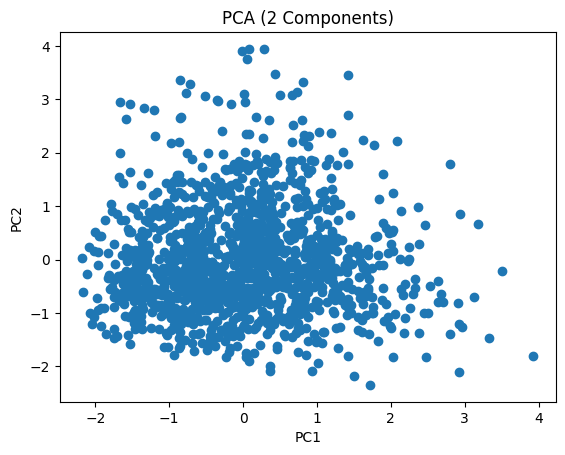

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.title("PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()